# Task 1


In [33]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   fixed acidity         4898 non-null   str  
 1   volatile acidity      4898 non-null   str  
 2   citric acid           4898 non-null   str  
 3   residual sugar        4898 non-null   str  
 4   chlorides             4898 non-null   str  
 5   free sulfur dioxide   4898 non-null   str  
 6   total sulfur dioxide  4898 non-null   str  
 7   density               4898 non-null   str  
 8   pH                    4898 non-null   str  
 9   sulphates             4898 non-null   str  
 10  alcohol               4898 non-null   str  
dtypes: str(11)
memory usage: 421.1 KB
     fixed acidity volatile acidity citric acid residual sugar chlorides  \
0              7.0             0.27        0.36           20.7     0.045   
1              6.3              0.3        0.34            1.6     0.049   


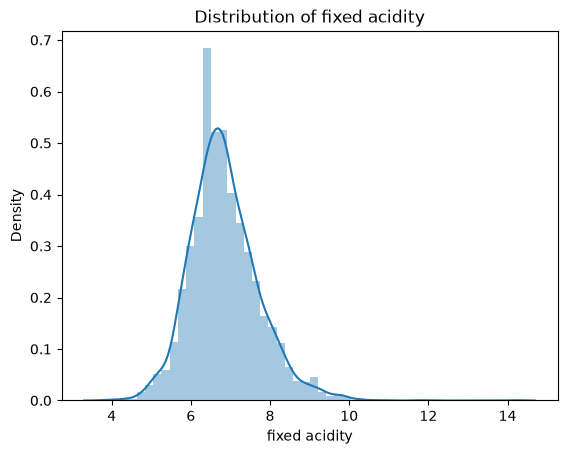

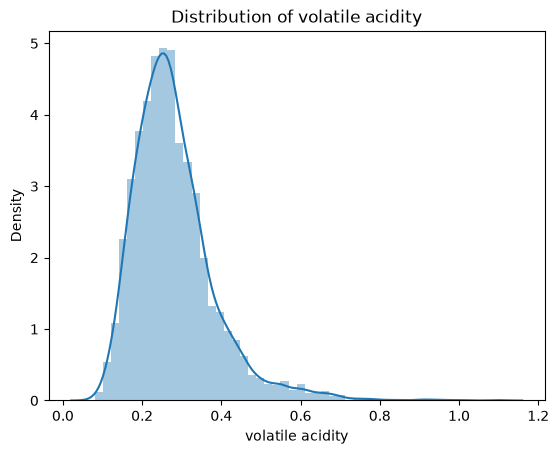

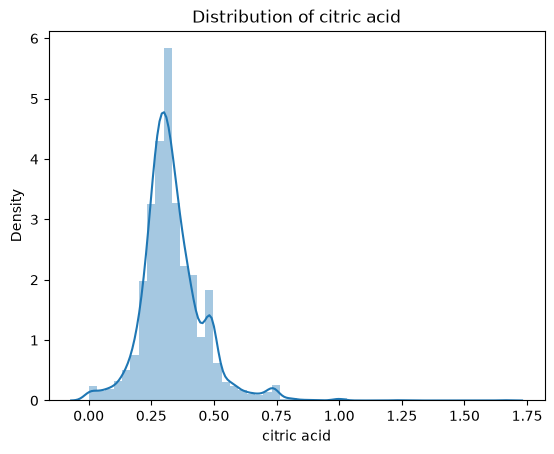

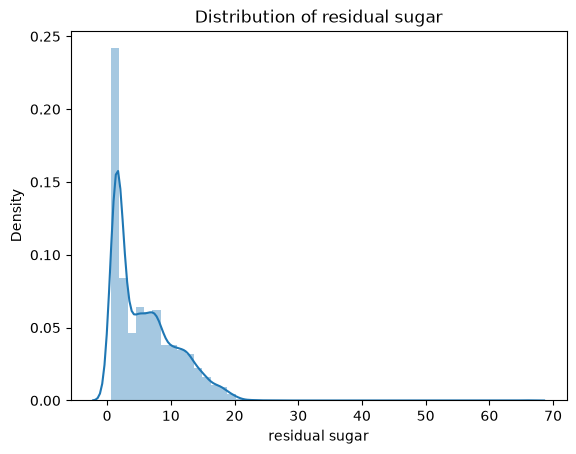

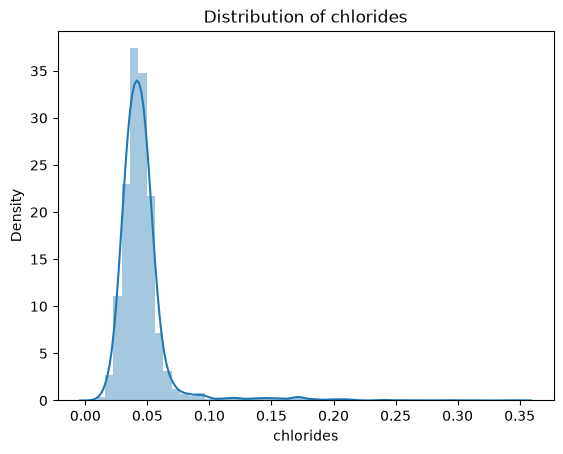

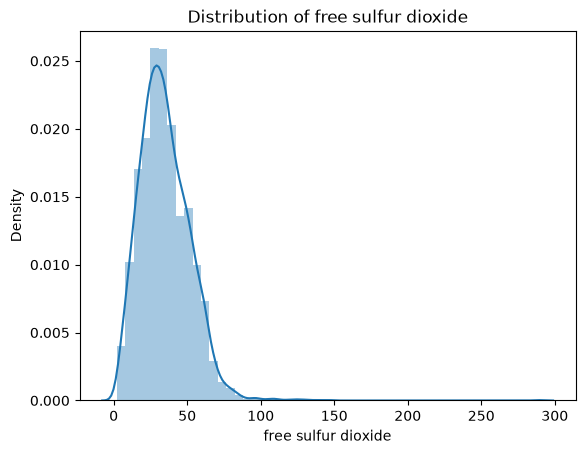

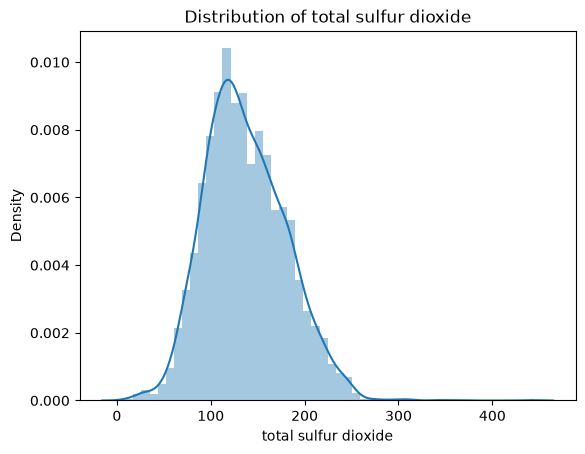

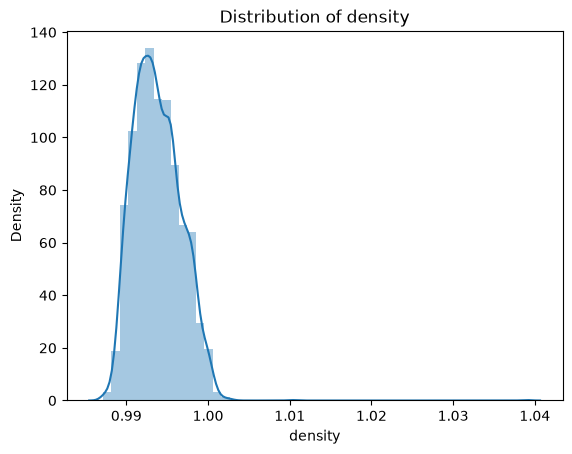

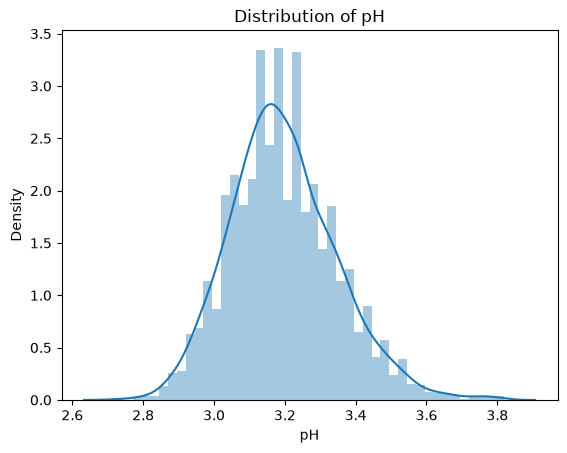

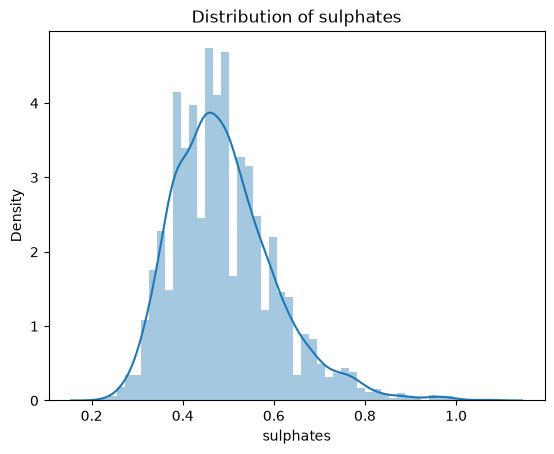

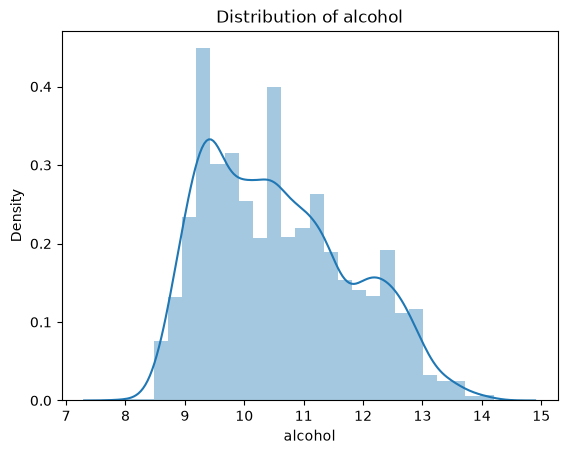

<class 'pandas.DataFrame'>
Index: 3975 entries, 0 to 4897
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         3975 non-null   float64
 1   volatile acidity      3975 non-null   float64
 2   citric acid           3975 non-null   float64
 3   residual sugar        3975 non-null   float64
 4   chlorides             3975 non-null   float64
 5   free sulfur dioxide   3975 non-null   float64
 6   total sulfur dioxide  3975 non-null   float64
 7   density               3975 non-null   float64
 8   pH                    3975 non-null   float64
 9   sulphates             3975 non-null   float64
 10  alcohol               3975 non-null   float64
dtypes: float64(11)
memory usage: 372.7 KB


In [34]:
## data cleaning

df = pd.read_csv('./CAB330_asm2_datasets/CAB330_asm2_datasets/Dataset4Task1_26.csv', na_filter=False)
df.info()


# check for duplicates
print(df[df.duplicated(keep=False)])
print("#### dupe check ####")
dupe_count = df.duplicated().sum()
print(dupe_count)

# export to observe duplicate entries
duplicates = df[df.duplicated(keep=False)]
duplicates = duplicates.sort_values(by=list(df.columns))
duplicates.to_excel('dupes.xlsx')


# convert data type from object to float. 
# conversion failed because of empty string entries
# scan to see number of empty strings

print("\n### Search for empty string entry ###")
count = 0
total_count = 0

for col in df.columns:
    count = (df[col] == '').sum()
    total_count += count
    if (count != 0):
        print(f"*{col}* empty count: {count}")
print(f"total empty count: {total_count}")

# convert empty entry into NaN

df = df.replace('', np.nan)

print("\n#### Check for NaN values ####")
null_count = 0
for col in df.columns:
    temp_count = df[col].isna().sum()
    null_count += temp_count

print(null_count)


# application of data cleaning process
df = df.drop_duplicates()
print("\n#### Duplication removal check ####")
dupe_count = df.duplicated().sum()
print(dupe_count)  # confirmed to have zero duplication

# change data type to float
df = df.astype(float)
df.info()

# addressing NaN values
to_be_deleted = []
for index, row in df.iterrows():
    row_null = 0
    for column in df.columns:
        if (pd.isna(row[column])):
            row_null += 1
    if row_null >= 2:
        to_be_deleted.append(index)
print(to_be_deleted)

# graph plot for each data point
for col in df.columns:
    sns.distplot(df[col].dropna())
    plt.title(f"Distribution of {col}")
    plt.show()

#fill with median
df = df.fillna(df.median())

df.info()

for cluster 2: inertia 3485596.4784301743 & sil score 0.5084327946827422
for cluster 3: inertia 2291923.698136157 & sil score 0.4150936999205016
for cluster 4: inertia 1743155.260583205 & sil score 0.37716719965819373
for cluster 5: inertia 1457155.1539902452 & sil score 0.34782852716202145
for cluster 6: inertia 1295345.1246656477 & sil score 0.32055418108364747
for cluster 7: inertia 1142817.1217064278 & sil score 0.3260591000073897
for cluster 8: inertia 1049015.4449532703 & sil score 0.2980748255759725
for cluster 9: inertia 955041.9645361454 & sil score 0.30026901580844606
for cluster 10: inertia 862686.9755022723 & sil score 0.3005874306100152
for cluster 11: inertia 805610.8049965566 & sil score 0.2962711183791102
for cluster 12: inertia 765694.4029004193 & sil score 0.2964101150186285
for cluster 13: inertia 708388.7285733667 & sil score 0.29727920571889077
for cluster 14: inertia 660353.0346157362 & sil score 0.29805070108397363
for cluster 15: inertia 629752.8237032822 & sil 

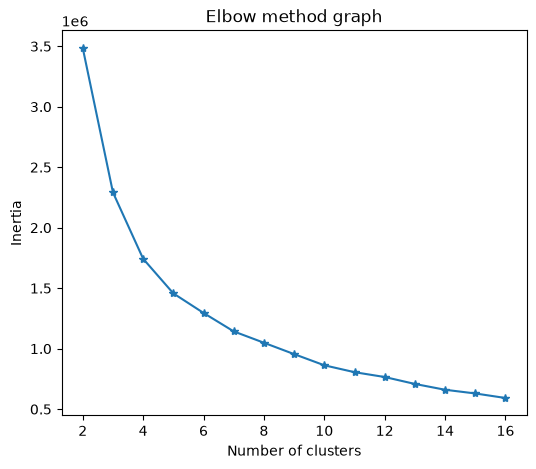

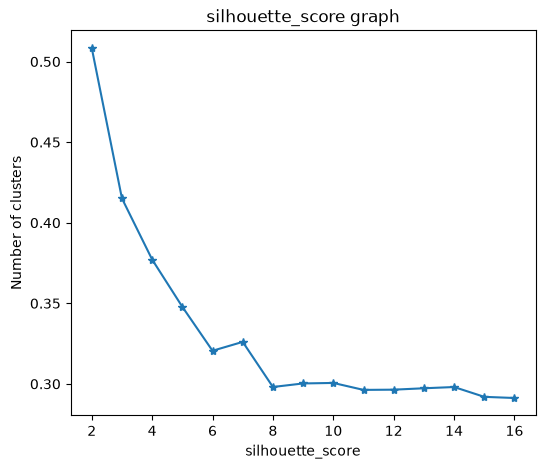

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

rs = 42
# 1.2: all variable K-means 
k_range = range(2, 17)

# stores cluster index, inertia and Silhouette score in that order 
clusters={}

for index in k_range:
    model = KMeans(n_clusters=index, random_state=rs)
    model.fit(df)

    inertia = model.inertia_
    sil_score = silhouette_score(df, model.labels_)

    clusters[index] = [inertia, sil_score]

for cluster, (inertia, sil_score) in clusters.items():
    print(f"for cluster {cluster}: inertia {inertia} & sil score {sil_score}")

# extract into seperate lists
cluster_list = list(clusters.keys())
inertia_list = []
sil_list = []
for i in clusters:
    inertia_list.append(clusters[i][0])
    sil_list.append(clusters[i][1])

plt.figure(figsize = (6,5))
plt.title("Elbow method graph")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.plot(cluster_list, inertia_list, marker="*")

plt.figure(figsize = (6,5))
plt.title("silhouette_score graph")
plt.xlabel("silhouette_score")
plt.ylabel("Number of clusters")
plt.plot(cluster_list, sil_list, marker="*")

# k = 6 was selected

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.020379     0.297176   
volatile acidity          -0.020379          1.000000    -0.162213   
citric acid                0.297176         -0.162213     1.000000   
residual sugar             0.082766          0.098617     0.106905   
chlorides                  0.022870          0.085686     0.132490   
free sulfur dioxide       -0.058855         -0.101712     0.090571   
total sulfur dioxide       0.081718          0.102071     0.121919   
density                    0.265214          0.060578     0.160534   
pH                        -0.431061         -0.047084    -0.181652   
sulphates                 -0.017541         -0.020365     0.049394   
alcohol                   -0.110727          0.047443    -0.076941   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity               0.082766   0.022870            -0.058855   
volatile acidit

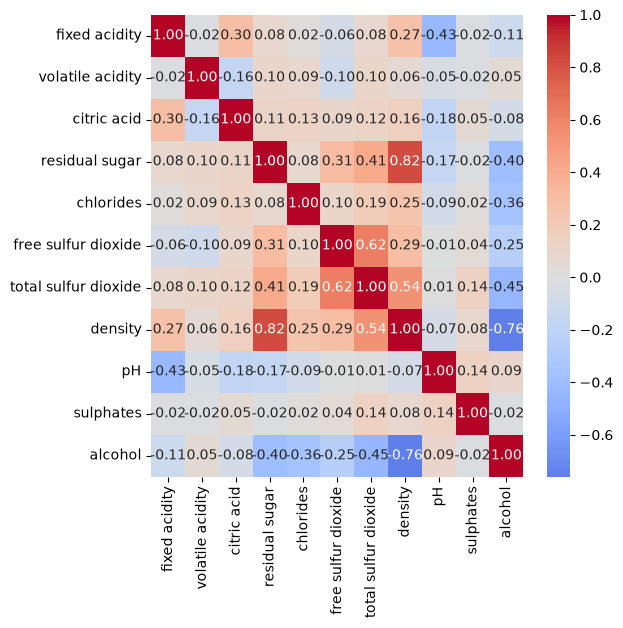

In [36]:
# part 3: 
matrix = df.corr()
print(matrix)
matrix.to_excel('corr.xlsx')
# free sulfur dioxide - explainable through tutal sulfur dioxide so redundnt
# chlorides - quality indicator (lower has better taste ratings) rather than a variable that should affect clustering that distinguishes wune type
# density - explained by other features such as sugar and alcohol 
# ph - derived from acidity measurements

plt.figure(figsize=(6,6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')

df2 = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'total sulfur dioxide', 'sulphates', 'alcohol']] 


### Cluster membership ###
1    1435
3    1150
2     872
0     518
Name: count, dtype: int64

Sum of intra-cluster distance for variable reduced clustering: 985335.462647841

### Centroid locations for variable reduced cluster ###
[6.96100386e+00 3.08137066e-01 3.57046332e-01 9.43484556e+00
 2.11548263e+02 5.18359073e-01 9.64652510e+00 2.22044605e-15]
[  6.77418118   0.27087456   0.32653659   5.0741115  122.22160279
   0.48409756  10.87536585   1.        ]
[ 6.77826835  0.27642775  0.31637615  3.41181193 83.47018349  0.47338303
 11.27454128  2.        ]
[  6.91221739   0.28327391   0.34726957   7.31386957 163.14826087
   0.49829565  10.13051884   3.        ]


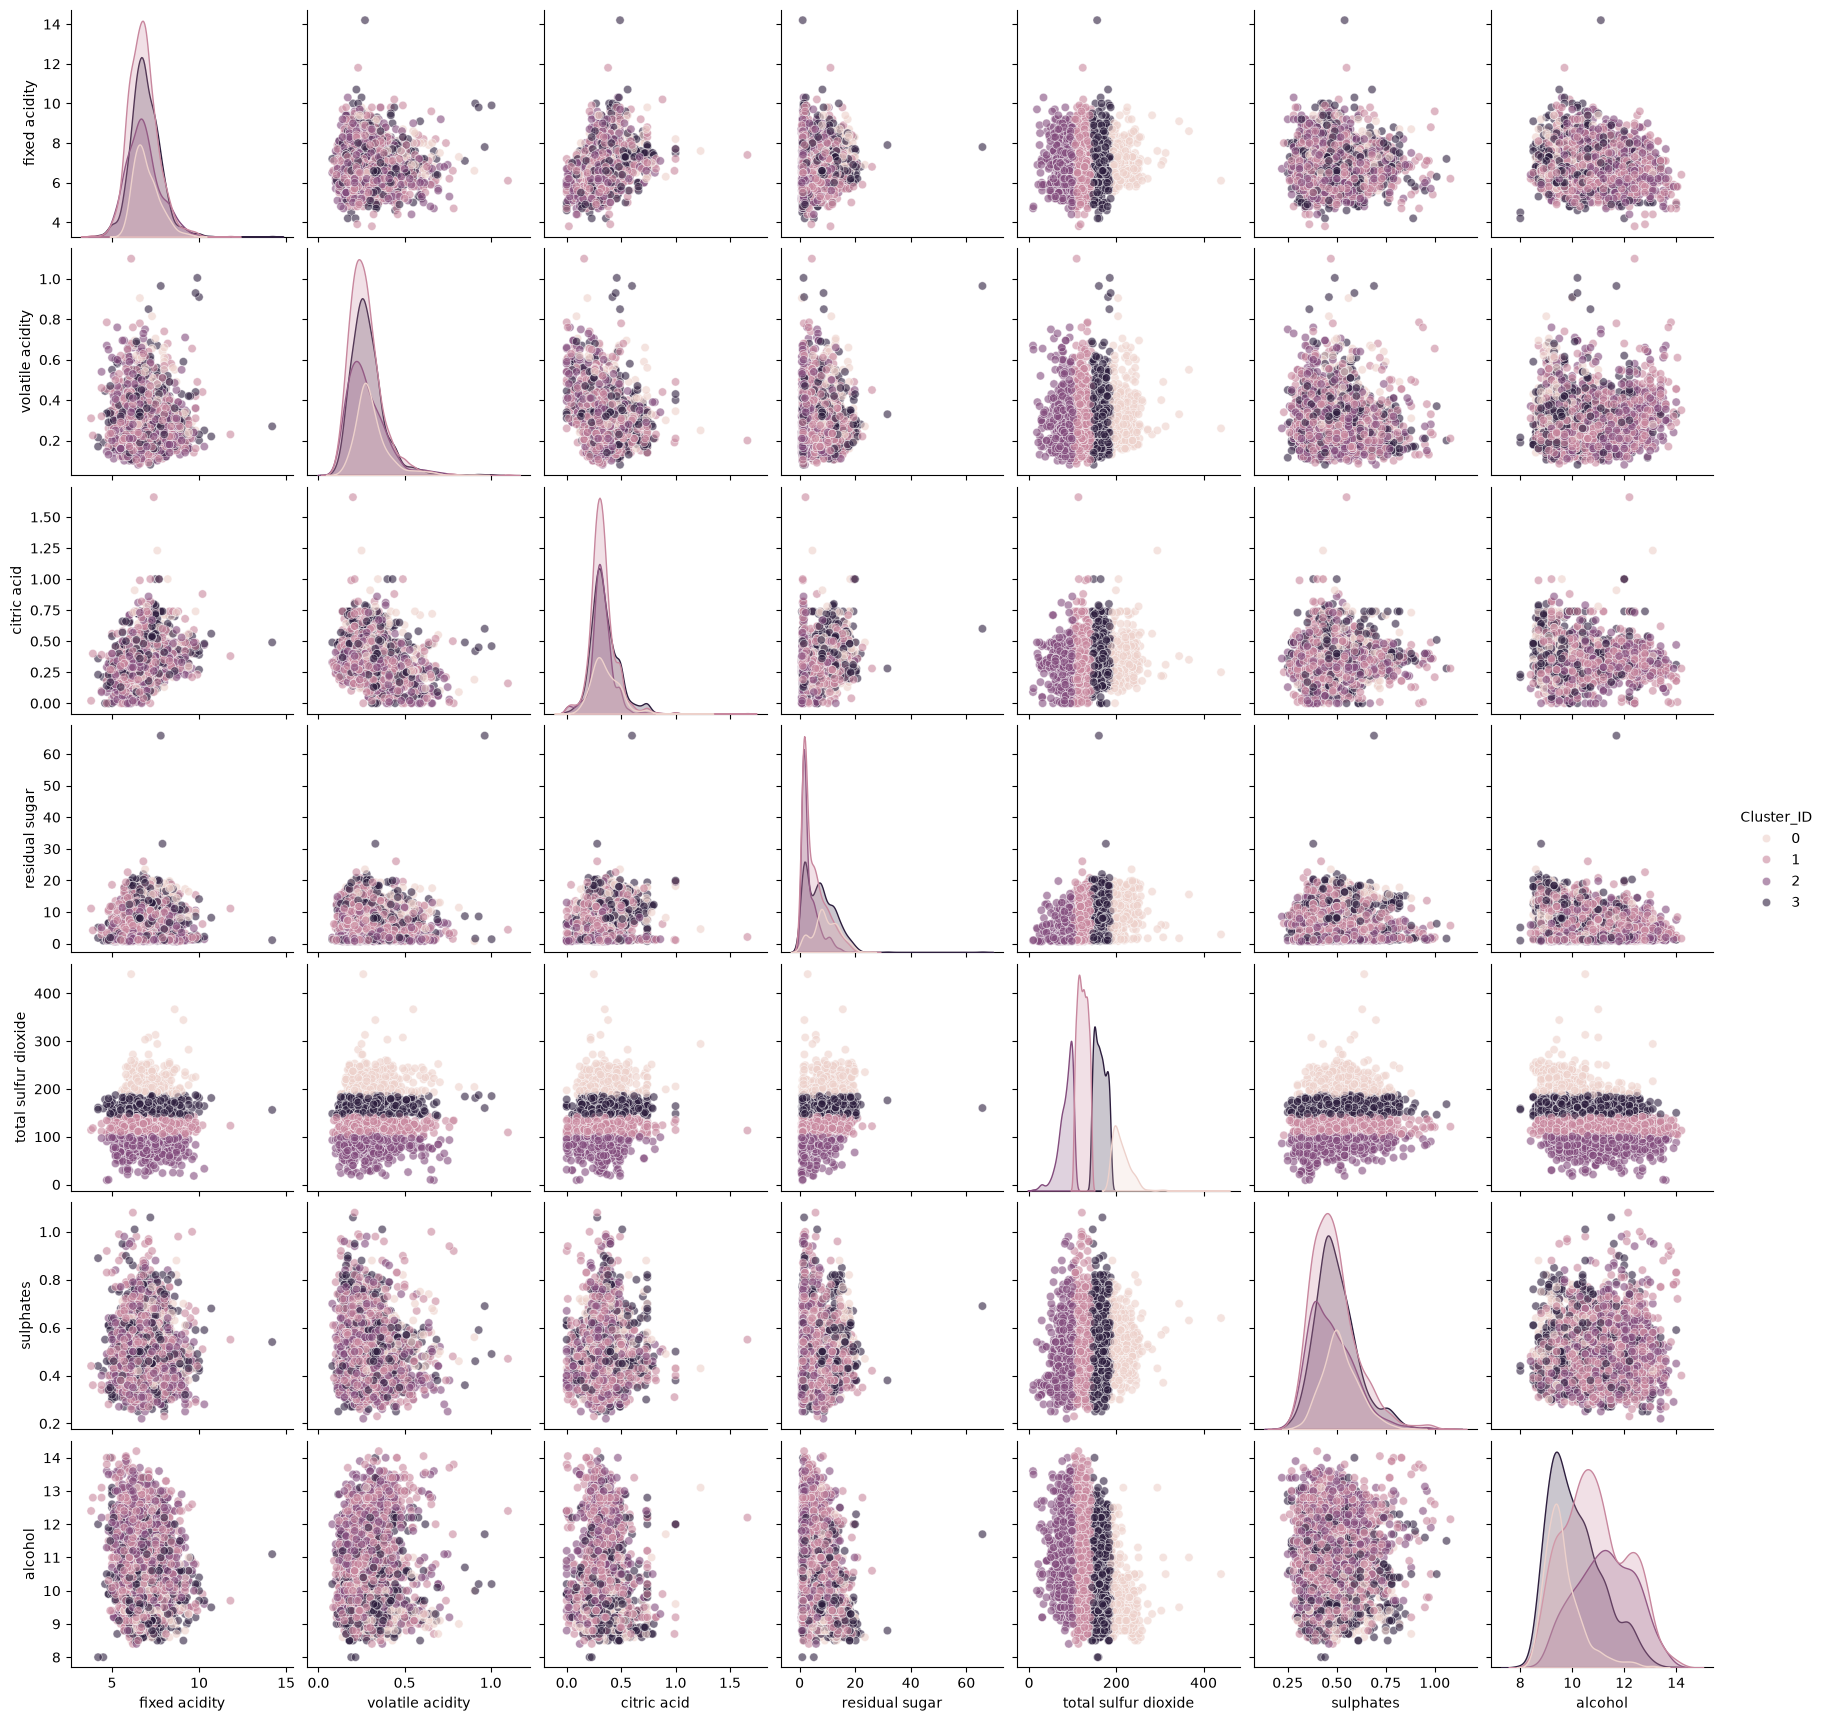

In [47]:
# section 4
df2.astype(float)
X = df2.values
reduced_model = KMeans(n_clusters=4, random_state=rs)
reduced_model.fit(X)



print("\n### Cluster membership ###")
labels = reduced_model.labels_
print(pd.Series(labels).value_counts())

print("\nSum of intra-cluster distance for variable reduced clustering:", reduced_model.inertia_)

print("\n### Centroid locations for variable reduced cluster ###")
for cen in reduced_model.cluster_centers_:
    print(cen)



y = reduced_model.predict(X)

df2['Cluster_ID'] = labels
cluster_g = sns.pairplot(df2, hue='Cluster_ID', plot_kws={'alpha': 0.6})
plt.savefig('pairwise.png', dpi=300, bbox_inches='tight')
plt.show()
df2.drop('Cluster_ID', axis=1, inplace=True)

In [ ]:
# use sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
